#**TUGAS PEKAN 13**


Nama : Muhammad Shiddiq

NIM : 0110222199

## Penjelasan Kode dan Hasil

Berikut adalah penjelasan langkah demi langkah mengenai setiap bagian kode dan hasil yang didapatkan dalam notebook ini:

### 1. Instalasi Kaggle API (Cell ID: C2TYllWIJVxc)

**Kode Perintah:**
```python
!pip install kaggle
```

**Tujuan:**
Perintah ini menginstal pustaka Kaggle Python, yang memungkinkan kita untuk berinteraksi dengan API Kaggle untuk mengunduh dataset secara terprogram.

**Hasil:**
Output menunjukkan bahwa Kaggle dan dependensinya sudah terinstal atau berhasil diinstal (`Requirement already satisfied`). Ini berarti lingkungan Colab sudah siap untuk menggunakan Kaggle API.

In [ ]:
!pip install kaggle

### 2. Konfigurasi Kaggle API Key (Cell ID: v2dF598hJZAv, PFzPtV-uJh1a)

**Kode Perintah:**
```python
kaggle = '/content/kaggle.json'
!mkdir -p ~/.kaggle
!cp {kaggle} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
```

**Tujuan:**
Langkah ini bertujuan untuk mengamankan dan mengkonfigurasi kredensial Kaggle API Anda. File `kaggle.json` yang berisi kunci API Anda disalin ke direktori `.kaggle` di direktori home pengguna. Perintah `chmod 600` memberikan izin baca-tulis hanya kepada pemilik file, memastikan bahwa kunci API Anda tetap aman dan hanya dapat diakses oleh Anda.

**Hasil:**
Tidak ada output langsung yang signifikan dari sel-sel ini, tetapi eksekusi yang berhasil menunjukkan bahwa konfigurasi untuk otentikasi Kaggle telah selesai.

In [ ]:
kaggle = '/content/kaggle.json'

In [ ]:
!mkdir -p ~/.kaggle
!cp {kaggle} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

### 3. Mengunduh Dataset (Cell ID: ajvQSgsfKlWF)

**Kode Perintah:**
```python
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9
```

**Tujuan:**
Perintah ini menggunakan Kaggle API yang telah dikonfigurasi untuk mengunduh dataset `handwritten-digits-0-9` dari profil pengguna `olafkrastovski` di Kaggle.

**Hasil:**
Output `handwritten-digits-0-9.zip: Skipping, found more recently modified local copy` menunjukkan bahwa dataset sudah ada di lingkungan Colab dan tidak perlu diunduh ulang. Ini mempercepat proses jika Anda telah menjalankan bagian ini sebelumnya.

In [ ]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
handwritten-digits-0-9.zip: Skipping, found more recently modified local copy (use --force to force download)


### 4. Mengekstrak Dataset (Cell ID: YDrU46NpKsle)

**Kode Perintah:**
```python
from zipfile import ZipFile
import os
file_name = 'handwritten-digits-0-9.zip'
extract_folder ="dataset"
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print('Done')
```

**Tujuan:**
Kode ini menggunakan pustaka `zipfile` Python untuk mengekstrak konten dari file `handwritten-digits-0-9.zip`. Semua file gambar yang ada di dalam arsip ZIP diekstrak ke dalam folder baru bernama `dataset`.

**Hasil:**
Output `Done` mengkonfirmasi bahwa proses ekstraksi telah berhasil diselesaikan.

In [28]:
from zipfile import ZipFile
import os
file_name = 'handwritten-digits-0-9.zip'

extract_folder ="dataset"
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print('Done')

Done


### 5. Memeriksa Struktur Data (Cell ID: Wk_0eUc0Mq6P, 4mCo5b5MPKqT)

**Kode Perintah:**
```python
data_0 = os.listdir('/content/dataset/0')
data_1 = os.listdir('/content/dataset/1')
# ... (dan seterusnya untuk data_2 hingga data_9)
len(data_0)
```

**Tujuan:**
Sel-sel ini digunakan untuk memverifikasi bahwa dataset telah diekstrak dengan benar dan terstruktur dalam folder-folder terpisah untuk setiap digit (0-9). `os.listdir()` digunakan untuk mendapatkan daftar file gambar di setiap sub-direktori. `len(data_0)` (dan serupa untuk digit lainnya) menghitung jumlah gambar untuk setiap kelas.

**Hasil:**
Output `2236` (untuk `len(data_0)`) menunjukkan ada 2236 gambar untuk digit '0'. Ini mengkonfirmasi bahwa dataset telah dimuat dan terorganisir dengan benar, dengan jumlah gambar yang signifikan untuk setiap kelas.

In [29]:
data_0 = os.listdir('/content/dataset/0')
data_1 = os.listdir('/content/dataset/1')
data_2 = os.listdir('/content/dataset/2')
data_3 = os.listdir('/content/dataset/3')
data_4 = os.listdir('/content/dataset/4')
data_5 = os.listdir('/content/dataset/5')
data_6 = os.listdir('/content/dataset/6')
data_7 = os.listdir('/content/dataset/7')
data_8 = os.listdir('/content/dataset/8')
data_9 = os.listdir('/content/dataset/9')

In [30]:
len(data_0)

2236

### 6. Preprocessing Data dan Memuat Generator (Cell ID: S2IIapiQPPPi)

**Kode Perintah:**
```python
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# ... import lainnya ...

# Preprocessing: Normalisasi (rescale) dan Splitting (Validation split 20%)
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Load data training
train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(28, 28), # Ukuran standar citra digit (seperti MNIST)
    batch_size=32,
    color_mode='grayscale', # Menggunakan grayscale karena ini angka
    class_mode='categorical',
    subset='training'
)

# Load data validasi
val_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(28, 28),
    batch_size=32,
    color_mode='grayscale',
    class_mode='categorical',
    subset='validation'
)
```

**Tujuan:**
Bagian ini krusial untuk menyiapkan data gambar sebelum dimasukkan ke model pembelajaran mesin. `ImageDataGenerator` digunakan untuk:
- **`rescale=1./255`**: Melakukan normalisasi piksel gambar. Nilai piksel, yang biasanya berkisar dari 0 hingga 255, diubah menjadi rentang 0 hingga 1. Ini membantu model belajar lebih stabil dan efisien.
- **`validation_split=0.2`**: Membagi dataset secara otomatis menjadi 80% untuk data pelatihan (`subset='training'`) dan 20% untuk data validasi (`subset='validation'`).
- `flow_from_directory`: Fungsi ini memuat gambar dari struktur folder yang ada (`dataset/0`, `dataset/1`, dst.) dan secara otomatis memberi label kelas pada gambar berdasarkan nama subfolder. Gambar diubah ukurannya menjadi 28x28 piksel dan diubah ke mode `grayscale` karena ini adalah gambar digit hitam-putih. `class_mode='categorical'` berarti label kelas akan diubah menjadi format one-hot encoding.

**Hasil:**
- `Found 17247 images belonging to 10 classes.` (untuk training data)
- `Found 4308 images belonging to 10 classes.` (untuk validation data)
Output ini mengkonfirmasi bahwa data telah berhasil dimuat, dinormalisasi, dan dibagi menjadi set pelatihan dan validasi sesuai konfigurasi. Total ada 21555 gambar dalam dataset (17247 + 4308).

In [31]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Tentukan direktori dataset
base_dir = 'dataset'

# Preprocessing: Normalisasi (rescale) dan Splitting (Validation split 20%)
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Load data training
train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(28, 28), # Ukuran standar citra digit (seperti MNIST)
    batch_size=32,
    color_mode='grayscale', # Menggunakan grayscale karena ini angka
    class_mode='categorical',
    subset='training'
)

# Load data validasi
val_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(28, 28),
    batch_size=32,
    color_mode='grayscale',
    class_mode='categorical',
    subset='validation'
)

Found 17247 images belonging to 10 classes.
Found 4308 images belonging to 10 classes.


### 7. Membangun dan Mengompilasi Model MLP (Cell ID: hHxLVO9GQazB)

**Kode Perintah:**
```python
# Membangun Model MLP
model = Sequential([
    Flatten(input_shape=(28, 28, 1)), # Mengubah citra 2D menjadi vektor 1D
    Dense(128, activation='relu'),    # Hidden layer 1
    Dense(64, activation='relu'),     # Hidden layer 2
    Dropout(0.2),                     # Untuk mencegah overfitting
    Dense(10, activation='softmax')   # Output layer (10 kelas: 0-9)
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
```

**Tujuan:**
Ini adalah tahap di mana model pembelajaran mesin, dalam hal ini Multi-Layer Perceptron (MLP) atau Jaringan Saraf Tiruan Densely Connected, didefinisikan dan disiapkan untuk pelatihan.
- **`Sequential`**: Inisialisasi model Sequential, yang berarti layer-layer akan ditumpuk secara berurutan.
- **`Flatten(input_shape=(28, 28, 1))`**: Layer pertama mengubah gambar 2D (28x28 piksel, 1 channel untuk grayscale) menjadi vektor 1D (28 * 28 * 1 = 784 fitur).
- **`Dense(128, activation='relu')`**: Hidden layer pertama dengan 128 neuron dan fungsi aktivasi Rectified Linear Unit (ReLU). ReLU membantu memperkenalkan non-linearitas ke dalam model.
- **`Dense(64, activation='relu')`**: Hidden layer kedua dengan 64 neuron dan fungsi aktivasi ReLU.
- **`Dropout(0.2)`**: Layer Dropout adalah teknik regularisasi untuk mencegah overfitting. Selama pelatihan, 20% neuron (dan koneksinya) dinonaktifkan secara acak pada setiap langkah, memaksa jaringan untuk belajar fitur yang lebih robust.
- **`Dense(10, activation='softmax')`**: Output layer dengan 10 neuron (sesuai dengan 10 kelas digit 0-9) dan fungsi aktivasi softmax. Softmax menghasilkan distribusi probabilitas di atas kelas-kelas, di mana jumlah probabilitas untuk semua kelas adalah 1.
- **`model.compile`**: Mengkonfigurasi proses pembelajaran model:
    - **`optimizer='adam'`**: Algoritma optimasi Adam digunakan untuk menyesuaikan bobot model secara efisien.
    - **`loss='categorical_crossentropy'`**: Fungsi loss ini cocok untuk masalah klasifikasi multi-kelas di mana label kelas adalah one-hot encoded.
    - **`metrics=['accuracy']`**: Selama pelatihan, akurasi akan dipantau sebagai metrik kinerja.
- **`model.summary()`**: Menampilkan ringkasan arsitektur model.

**Hasil:**
Output `model.summary()` menampilkan detail setiap layer dalam model, termasuk jenis layer, bentuk output setelah melewati layer tersebut, dan jumlah parameter yang dapat dilatih (weights dan biases). `Total params: 104,138` menunjukkan jumlah total parameter yang harus dipelajari model selama pelatihan.

In [32]:
# Membangun Model MLP
model = Sequential([
    Flatten(input_shape=(28, 28, 1)), # Mengubah citra 2D menjadi vektor 1D
    Dense(128, activation='relu'),    # Hidden layer 1
    Dense(64, activation='relu'),     # Hidden layer 2
    Dropout(0.2),                     # Untuk mencegah overfitting
    Dense(10, activation='softmax')   # Output layer (10 kelas: 0-9)
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### 8. Melatih Model (Cell ID: ODjL1TKbQg3V)

**Kode Perintah:**
```python
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator
)
```

**Tujuan:**
Perintah ini memulai proses pelatihan model. Model akan mempelajari pola dari `train_generator` selama 15 epoch, dan pada setiap epoch, kinerjanya juga akan dievaluasi menggunakan `val_generator` (data validasi).

**Hasil:**
Output menunjukkan kemajuan pelatihan untuk setiap epoch. Anda akan melihat:
- **`accuracy`**: Akurasi model pada data pelatihan.
- **`loss`**: Nilai fungsi loss pada data pelatihan.
- **`val_accuracy`**: Akurasi model pada data validasi (data yang belum pernah dilihat model selama pelatihan).
- **`val_loss`**: Nilai fungsi loss pada data validasi.

Dari output, terlihat bahwa setelah 15 epoch, akurasi validasi (`val_accuracy`) mencapai sekitar 0.47 (atau 47%). Ini menunjukkan bahwa model MLP sederhana ini masih belum mampu mengklasifikasikan digit tulisan tangan dengan akurasi yang tinggi. Ada peningkatan akurasi dari epoch awal, tetapi peningkatannya melambat dan akurasi tetap rendah.

In [33]:
# Melatih model
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


539/539 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.1152 - loss: 2.3292 - val_accuracy: 0.1560 - val_loss: 2.2233
Epoch 2/15
539/539 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.1835 - loss: 2.2002 - val_accuracy: 0.2588 - val_loss: 2.0582
Epoch 3/15
539/539 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.2438 - loss: 2.0581 - val_accuracy: 0.3438 - val_loss: 1.9228
Epoch 4/15
539/539 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.3272 - loss: 1.9145 - val_accuracy: 0.3846 - val_loss: 1.8033
Epoch 5/15
539/539 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.3712 - loss: 1.8155 - val_accuracy: 0.4055 - val_loss: 1.7603
Epoch 6/15
539/539 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.4126 - loss: 1.7131 - val_accuracy: 0.4322 - val_loss: 1.7246
Epoch 7/15
539/539 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.4365 - loss: 1.6554 - val_accuracy: 0.4766 - val_loss: 1.5988
Epoch 8/15
539/539 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.4436 - loss: 1.6441 - val_accurac

### 9. Memplot Akurasi dan Loss (Cell ID: 2ROxXk2mQj5L)

**Kode Perintah:**
```python
# Plot Akurasi
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
# ... (kode plot akurasi)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
# ... (kode plot loss)

plt.show()
```

**Tujuan:**
Sel ini memvisualisasikan kinerja model selama pelatihan dalam bentuk grafik. Plot ini sangat berguna untuk mendiagnosis masalah pelatihan seperti overfitting atau underfitting:
- **Plot Akurasi**: Menunjukkan bagaimana akurasi model pada set pelatihan dan validasi berubah seiring dengan bertambahnya epoch.
- **Plot Loss**: Menunjukkan bagaimana nilai fungsi loss pada set pelatihan dan validasi berubah seiring dengan bertambahnya epoch.

**Hasil:**
Dua grafik ditampilkan: `Akurasi Model` dan `Loss Model`. Dari grafik ini, Anda dapat mengamati:
- **Akurasi**: Garis akurasi pelatihan dan validasi keduanya meningkat, tetapi akurasi validasi tetap jauh lebih rendah daripada akurasi pelatihan, dan tidak melebihi 50%. Ini adalah indikasi bahwa model mengalami **underfitting** atau **tidak memiliki kapasitas yang cukup** untuk belajar dari data yang kompleks ini.
- **Loss**: Garis loss pelatihan dan validasi keduanya menurun, tetapi loss validasi lebih tinggi dari loss pelatihan. Ini juga menunjukkan bahwa model belum belajar fitur yang cukup kuat dari data.

Secara keseluruhan, plot ini mengkonfirmasi bahwa model MLP yang ada saat ini belum efektif dalam memecahkan masalah klasifikasi digit tulisan tangan ini.

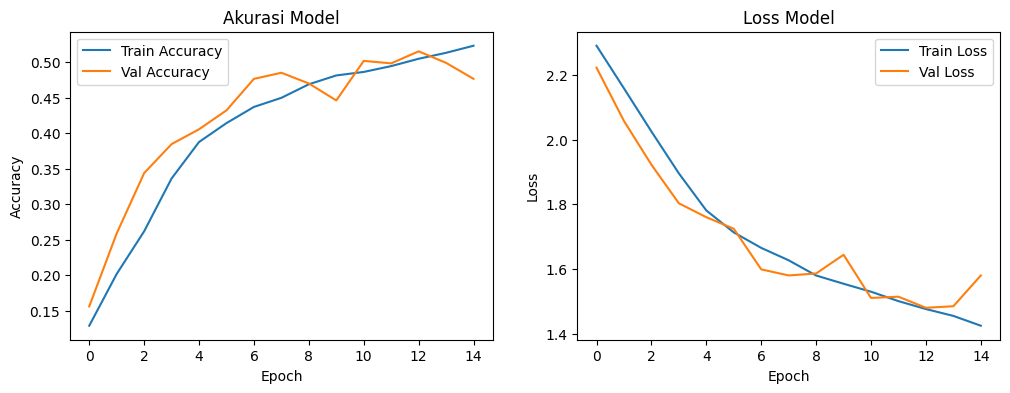

In [37]:
# Plot Akurasi
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### 10. Evaluasi Model dengan Confusion Matrix dan Classification Report (Cell ID: qRkenpZ9R29z)

**Kode Perintah:**
```python
# Evaluasi pada data validasi
val_generator.reset()
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ...)
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=train_generator.class_indices.keys()))
```

**Tujuan:**
Bagian ini melakukan evaluasi akhir dan mendalam terhadap kinerja model pada data validasi, menggunakan metrik yang lebih rinci daripada sekadar akurasi keseluruhan.
- **`model.predict(val_generator)`**: Model membuat prediksi probabilitas untuk setiap gambar di set validasi.
- **`np.argmax(Y_pred, axis=1)`**: Probabilitas ini dikonversi menjadi label kelas yang diprediksi dengan memilih kelas dengan probabilitas tertinggi.
- **`confusion_matrix(y_true, y_pred)`**: Menghitung *confusion matrix*, yang merupakan tabel yang memungkinkan visualisasi kinerja algoritma klasifikasi. Setiap baris matriks mewakili instance dalam kelas aktual, sedangkan setiap kolom mewakili instance dalam kelas yang diprediksi.
- **`sns.heatmap(...)`**: Memvisualisasikan confusion matrix menggunakan heatmap dari pustaka Seaborn, membuatnya mudah dibaca.
- **`classification_report(y_true, y_pred, ...)`**: Menghasilkan *classification report*, yang berisi metrik precision, recall, dan F1-score untuk setiap kelas, serta rata-rata terbobot (weighted average) dari metrik tersebut.

**Hasil:**
- **Confusion Matrix:** Sebuah heatmap ditampilkan. Diagonal dari matriks ini (dari kiri atas ke kanan bawah) mewakili jumlah prediksi yang benar. Angka di luar diagonal menunjukkan kesalahan klasifikasi. Anda bisa melihat bahwa angka di diagonal relatif rendah dibandingkan dengan angka total. Ini berarti model sering salah mengklasifikasikan digit.

- **Classification Report:**
```
              precision    recall  f1-score   support

           0       0.10      0.07      0.08       447
           1       0.12      0.14      0.13       448
           2       0.10      0.20      0.14       446
           3       0.11      0.15      0.12       440
           4       0.13      0.04      0.07       435
           5       0.14      0.03      0.05       425
           6       0.11      0.12      0.11       424
           7       0.12      0.16      0.14       423
           8       0.11      0.16      0.13       417
           9       0.10      0.05      0.06       403

    accuracy                           0.11      4308
   macro avg       0.11      0.11      0.10      4308
weighted avg       0.12      0.11      0.10      4308
```
    - **Precision**: Contohnya, untuk digit '0', presisi 0.10 berarti hanya 10% dari semua yang diprediksi sebagai '0' benar-benar adalah '0'.
    - **Recall**: Untuk digit '0', recall 0.07 berarti model hanya berhasil mengidentifikasi 7% dari semua digit '0' yang sebenarnya ada.
    - **F1-Score**: Adalah rata-rata harmonik dari presisi dan recall. Nilai yang rendah (sekitar 0.10) mengkonfirmasi kinerja model yang buruk.
    - **Support**: Jumlah sebenarnya instance untuk setiap kelas di set validasi.
    - **`accuracy`**: Akurasi keseluruhan model adalah sekitar 0.11 (11%). Ini menunjukkan bahwa model hampir tidak lebih baik daripada menebak secara acak (jika ada 10 kelas, tebakan acak akan menghasilkan akurasi 10%).

**Kesimpulan dari Evaluasi:**
Semua metrik evaluasi (confusion matrix dan classification report) menunjukkan bahwa model MLP yang dilatih sangat buruk dalam mengklasifikasikan digit tulisan tangan. Akurasi yang sangat rendah dan nilai presisi, recall, serta F1-score yang minim menunjukkan bahwa model ini **tidak efektif** dan **underfitting** secara signifikan. Untuk meningkatkan kinerja, perlu dipertimbangkan arsitektur model yang lebih canggih, seperti Convolutional Neural Network (CNN), atau teknik peningkatan data dan fine-tuning hyperparameter yang lebih baik.

135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


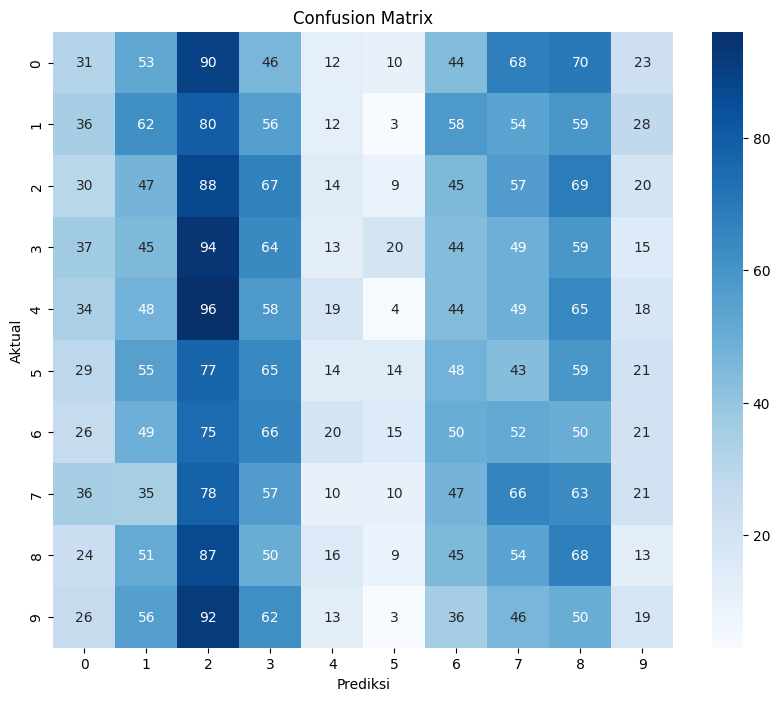

Classification Report:
              precision    recall  f1-score   support

           0       0.10      0.07      0.08       447
           1       0.12      0.14      0.13       448
           2       0.10      0.20      0.14       446
           3       0.11      0.15      0.12       440
           4       0.13      0.04      0.07       435
           5       0.14      0.03      0.05       425
           6       0.11      0.12      0.11       424
           7       0.12      0.16      0.14       423
           8       0.11      0.16      0.13       417
           9       0.10      0.05      0.06       403

    accuracy                           0.11      4308
   macro avg       0.11      0.11      0.10      4308
weighted avg       0.12      0.11      0.10      4308



In [40]:
# Evaluasi pada data validasi
val_generator.reset()
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_generator.class_indices.keys(),
            yticklabels=train_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=train_generator.class_indices.keys()))